In [ ]:
import pandas as pd
import os

# Define the mapping of files to their scenario labels
file_mapping = {
    '/content/anesthesiainduction_demoResults.csv': 'anesthesia',
    '/content/oxygentankpressurelossResults.csv': 'oxygen_tank',
    '/content/oxygenwallpressurelossResults.csv': 'oxygen_wall',
    '/content/expiratoryvalveobstructionvariedResults.csv': 'valve_obstruction',
    '/content/ventilatorpressurelossvariedResults.csv': 'ventilator_failure',
    '/content/inspiratoryvalveleakvariedResults.csv': 'valve_leak'
}

# List to store dataframes
dataframes = []

# Load, label, and append each file
for file_path, scenario in file_mapping.items():
    if os.path.exists(file_path):
        temp_df = pd.read_csv(file_path)
        temp_df['scenario'] = scenario
        dataframes.append(temp_df)
        print(f"Loaded {scenario} from {os.path.basename(file_path)}")

# Merge all dataframes into one
if dataframes:
    merged_df = pd.concat(dataframes, ignore_index=True)
    print("\nSuccessfully merged all datasets.")
    display(merged_df.head())
    print(f"Total rows: {len(merged_df)}")
else:
    print("No files were found to merge.")

Loaded anesthesia from anesthesiainduction_demoResults.csv
Loaded oxygen_tank from oxygentankpressurelossResults.csv
Loaded oxygen_wall from oxygenwallpressurelossResults.csv
Loaded valve_obstruction from expiratoryvalveobstructionvariedResults.csv
Loaded ventilator_failure from ventilatorpressurelossvariedResults.csv
Loaded valve_leak from inspiratoryvalveleakvariedResults.csv

Successfully merged all datasets.


,Time(s),CTSresistance,PatientWeight(kg),HeartRate(1/min),HeartStrokeVolume(mL),BloodVolume(L),ExtravascularFluidVolume(L),ArterialPressure(mmHg),MeanArterialPressure(mmHg),SystolicArterialPressure(mmHg),...,Ventilator-Volume(mL),ReliefValve-InFlow(L/min),Selector-Pressure(cmH2O),Ventilator-Pressure(cmH2O),ExpiratoryLimb-InFlow(L/min),InspiratoryLimb-InFlow(L/min),GasInlet-Oxygen-VolumeFraction,GasInlet-CarbonDioxide-VolumeFraction,Propofol-PlasmaConcentration(ug/L),scenario
0,0.02,0,77.6,72.0,80.3,5.53,34.4,104.5,95.9,115,...,1516,0,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
1,0.04,0,77.6,72.0,80.3,5.53,34.4,107.9,95.9,115,...,1516,0,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
2,0.06,0,77.6,72.0,80.3,5.53,34.4,110.6,95.9,115,...,1516,0,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
3,0.08,0,77.6,72.0,80.3,5.53,34.4,112.4,95.9,115,...,1516,0,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
4,0.10,0,77.6,72.0,80.3,5.53,34.4,113.7,95.9,115,...,1516,0,1033,1034,0,0,0.21,0.0004,0.0,anesthesia


Total rows: 100081


### How to isolate scenarios
You can now easily filter the `merged_df` using the `scenario` column:

```python
# Example: Get only the anesthesia data
anesthesia_data = merged_df[merged_df['scenario'] == 'anesthesia']
display(anesthesia_data.head())
```

In [ ]:
import pandas as pd

# 1. Check for missing values before processing
print("Missing values per column (Top 10):")
print(merged_df.isnull().sum().sort_values(ascending=False).head(10))

# 2. Fill NaN values with 0 as requested
# This handles the case where extra columns only exist for certain scenarios
merged_df_cleaned = merged_df.fillna(0)

# 3. Identify and remove constant columns (columns with only one unique value)
# These often don't help in machine learning or analysis
constant_cols = [col for col in merged_df_cleaned.columns if merged_df_cleaned[col].nunique() <= 1 and col != 'scenario']
merged_df_cleaned.drop(columns=constant_cols, inplace=True)

# 4. Remove duplicate rows if any
initial_count = len(merged_df_cleaned)
merged_df_cleaned.drop_duplicates(inplace=True)
final_count = len(merged_df_cleaned)

print(f"\nPreprocessing complete:")
print(f"- Filled missing values with 0.")
print(f"- Removed {len(constant_cols)} constant columns: {constant_cols}")
print(f"- Removed {initial_count - final_count} duplicate rows.")
print(f"- New shape: {merged_df_cleaned.shape}")

display(merged_df_cleaned.head())


Missing values per column (Top 10):
Propofol-PlasmaConcentration(ug/L)    77257
AnesthesiaConnection-InFlow(L/min)    77257
TotalPulmonaryVentilation(L/min)      77257
RichmondAgitationSedationScale        77257
PatientWeight(kg)                         0
Time(s)                                   0
CTSresistance                             0
ArterialPressure(mmHg)                    0
HeartRate(1/min)                          0
BloodVolume(L)                            0
dtype: int64

Preprocessing complete:
- Filled missing values with 0.
- Removed 8 constant columns: ['CTSresistance', 'PatientWeight(kg)', 'ExtravascularFluidVolume(L)', 'HemoglobinContent(g)', 'LeftAfferentArterioleResistance(mmHg_min/mL)', 'RightAfferentArterioleResistance(mmHg_min/mL)', 'LiverGlycogen(g)', 'ReliefValve-InFlow(L/min)']
- Removed 0 duplicate rows.
- New shape: (100081, 59)


,Time(s),HeartRate(1/min),HeartStrokeVolume(mL),BloodVolume(L),ArterialPressure(mmHg),MeanArterialPressure(mmHg),SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),CardiacOutput(L/min),CentralVenousPressure(mmHg),...,AnesthesiaConnection-InFlow(L/min),Ventilator-Volume(mL),Selector-Pressure(cmH2O),Ventilator-Pressure(cmH2O),ExpiratoryLimb-InFlow(L/min),InspiratoryLimb-InFlow(L/min),GasInlet-Oxygen-VolumeFraction,GasInlet-CarbonDioxide-VolumeFraction,Propofol-PlasmaConcentration(ug/L),scenario
0,0.02,72.0,80.3,5.53,104.5,95.9,115,74.5,5.78,3.92,...,0.0,1516,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
1,0.04,72.0,80.3,5.53,107.9,95.9,115,74.5,5.78,3.93,...,0.0,1516,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
2,0.06,72.0,80.3,5.53,110.6,95.9,115,74.5,5.78,3.93,...,0.0,1516,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
3,0.08,72.0,80.3,5.53,112.4,95.9,115,74.5,5.78,3.94,...,0.0,1516,1033,1034,0,0,0.21,0.0004,0.0,anesthesia
4,0.10,72.0,80.3,5.53,113.7,95.9,115,74.5,5.78,3.95,...,0.0,1516,1033,1034,0,0,0.21,0.0004,0.0,anesthesia


In [ ]:
import pandas as pd
import os

file_mapping = {
    '/content/anesthesiainduction_demoResults.csv': 'anesthesia',
    '/content/oxygentankpressurelossResults.csv': 'oxygen_tank',
    '/content/oxygenwallpressurelossResults.csv': 'oxygen_wall',
    '/content/expiratoryvalveobstructionvariedResults.csv': 'valve_obstruction',
    '/content/ventilatorpressurelossvariedResults.csv': 'ventilator_failure',
    '/content/inspiratoryvalveleakvariedResults.csv': 'valve_leak'
}

# 1. Strictly find columns that exist in ALL files
column_sets = []
for file_path in file_mapping.keys():
    if os.path.exists(file_path):
        cols = set(pd.read_csv(file_path, nrows=0).columns)
        column_sets.append(cols)

# Intersection of all sets
final_common_cols = list(set.intersection(*column_sets))
final_common_cols = sorted(final_common_cols)

print(f"Strict common columns found: {len(final_common_cols)}")

# 2. Re-merge using only these strictly common columns
final_dfs = []
for file_path, scenario in file_mapping.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, usecols=final_common_cols)
        df['scenario'] = scenario
        final_dfs.append(df)

merged_consistent_df = pd.concat(final_dfs, ignore_index=True)

# 3. Double check: Is there any column with nulls now?
null_counts = merged_consistent_df.isnull().sum().sum()
print(f"Total null values in new dataframe: {null_counts}")
print(f"Final shape: {merged_consistent_df.shape}")

display(merged_consistent_df.head())


Strict common columns found: 62
Total null values in new dataframe: 0
Final shape: (100081, 63)


,Time(s),CTSresistance,PatientWeight(kg),HeartRate(1/min),HeartStrokeVolume(mL),BloodVolume(L),ExtravascularFluidVolume(L),ArterialPressure(mmHg),MeanArterialPressure(mmHg),SystolicArterialPressure(mmHg),...,SedationLevel,Ventilator-Volume(mL),ReliefValve-InFlow(L/min),Selector-Pressure(cmH2O),Ventilator-Pressure(cmH2O),ExpiratoryLimb-InFlow(L/min),InspiratoryLimb-InFlow(L/min),GasInlet-Oxygen-VolumeFraction,GasInlet-CarbonDioxide-VolumeFraction,scenario
0,0.02,0,77.6,72.0,80.3,5.53,34.4,104.5,95.9,115,...,0.0,1516,0,1033,1034,0,0,0.21,0.0004,anesthesia
1,0.04,0,77.6,72.0,80.3,5.53,34.4,107.9,95.9,115,...,0.0,1516,0,1033,1034,0,0,0.21,0.0004,anesthesia
2,0.06,0,77.6,72.0,80.3,5.53,34.4,110.6,95.9,115,...,0.0,1516,0,1033,1034,0,0,0.21,0.0004,anesthesia
3,0.08,0,77.6,72.0,80.3,5.53,34.4,112.4,95.9,115,...,0.0,1516,0,1033,1034,0,0,0.21,0.0004,anesthesia
4,0.10,0,77.6,72.0,80.3,5.53,34.4,113.7,95.9,115,...,0.0,1516,0,1033,1034,0,0,0.21,0.0004,anesthesia


### Next Steps for Preprocessing
Since different sensors (Pressure, Flow, Volume) have very different scales (e.g., Pressure in thousands vs. Volume in decimals), you might want to consider **Scaling** or **Normalization** next if you plan to use this for Machine Learning.

In [ ]:
import pandas as pd
from google.colab import files

# Save the strictly consistent dataframe to a CSV file
merged_consistent_df.to_csv('/content/merged_consistent_scenarios.csv', index=False)

print("The new merged file (common features only) has been saved to: /content/merged_consistent_scenarios.csv")

# Trigger the download
files.download('/content/merged_consistent_scenarios.csv')

The new merged file (common features only) has been saved to: /content/merged_consistent_scenarios.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import os

file_path = '/content/merged_consistent_scenarios.csv'

if os.path.exists(file_path):
    # Read only the header to get attribute names efficiently without loading the whole file
    df_header = pd.read_csv(file_path, nrows=0)
    attributes = df_header.columns.tolist()

    print(f"Total attributes: {len(attributes)}")
    print("\nList of attributes:")
    for attr in attributes:
        print(f"- {attr}")
else:
    print(f"Error: {file_path} not found. Please ensure the file exists at the specified path.")

Total attributes: 63

List of attributes:
- Time(s)
- CTSresistance
- PatientWeight(kg)
- HeartRate(1/min)
- HeartStrokeVolume(mL)
- BloodVolume(L)
- ExtravascularFluidVolume(L)
- ArterialPressure(mmHg)
- MeanArterialPressure(mmHg)
- SystolicArterialPressure(mmHg)
- DiastolicArterialPressure(mmHg)
- CardiacOutput(L/min)
- HemoglobinContent(g)
- CentralVenousPressure(mmHg)
- PulmonaryCapillariesWedgePressure(mmHg)
- RespirationRate(1/min)
- OxygenSaturation
- CarbonDioxideSaturation
- TidalVolume(mL)
- TotalLungVolume(L)
- EndTidalCarbonDioxideFraction
- TotalAlveolarVentilation(L/min)
- TranspulmonaryPressure(cmH2O)
- RespiratoryExchangeRatio
- CoreTemperature(degC)
- SkinTemperature(degC)
- GlomerularFiltrationRate(mL/min)
- RenalBloodFlow(L/min)
- UrineProductionRate(mL/min)
- LeftAfferentArterioleResistance(mmHg_min/mL)
- RightAfferentArterioleResistance(mmHg_min/mL)
- OxygenConsumptionRate(mL/min)
- CarbonDioxideProductionRate(mL/min)
- LeftAlveoli-Pressure(cmH2O)
- LeftAlveoli-Oxy

# Task
Load the merged dataset from "/content/merged_consistent_scenarios.csv" and perform a correlation analysis on the numerical physiological attributes. Specifically, filter out the 'scenario' label and any constant columns, calculate the Pearson correlation matrix for the remaining attributes, and visualize the relationships using a Seaborn heatmap with annotations. Finally, summarize the strongest positive and negative correlations found in the data to provide insights into how the different physiological metrics relate to each other.

## Load and Filter Data

### Subtask:
Load the merged dataset and prepare it for correlation analysis by filtering out non-numerical and constant columns.


**Reasoning**:
I will load the merged dataset, filter for numerical features, and remove constant columns to prepare the data for correlation analysis.



In [ ]:
import pandas as pd

# 2. Load the dataset
df_correlation = pd.read_csv('/content/merged_consistent_scenarios.csv')

# 3. Identify and drop 'scenario' and 'Time(s)'
cols_to_drop = ['scenario', 'Time(s)']
df_correlation = df_correlation.drop(columns=[c for c in cols_to_drop if c in df_correlation.columns])

# 4. Filter to include only numeric columns
df_correlation = df_correlation.select_dtypes(include=['number'])

# 5. Identify and remove constant columns
# A column is constant if it has only one unique value
constant_cols = [col for col in df_correlation.columns if df_correlation[col].nunique() <= 1]
df_correlation.drop(columns=constant_cols, inplace=True)

# 6. Display the first few rows and shape
print(f"Removed constant columns: {constant_cols}")
print(f"Final shape for correlation: {df_correlation.shape}")
display(df_correlation.head())

Removed constant columns: ['CTSresistance', 'PatientWeight(kg)', 'ExtravascularFluidVolume(L)', 'HemoglobinContent(g)', 'LeftAfferentArterioleResistance(mmHg_min/mL)', 'RightAfferentArterioleResistance(mmHg_min/mL)', 'LiverGlycogen(g)', 'ReliefValve-InFlow(L/min)']
Final shape for correlation: (100081, 53)


,HeartRate(1/min),HeartStrokeVolume(mL),BloodVolume(L),ArterialPressure(mmHg),MeanArterialPressure(mmHg),SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),CardiacOutput(L/min),CentralVenousPressure(mmHg),PulmonaryCapillariesWedgePressure(mmHg),...,MuscleGlycogen(g),NeuromuscularBlockLevel,SedationLevel,Ventilator-Volume(mL),Selector-Pressure(cmH2O),Ventilator-Pressure(cmH2O),ExpiratoryLimb-InFlow(L/min),InspiratoryLimb-InFlow(L/min),GasInlet-Oxygen-VolumeFraction,GasInlet-CarbonDioxide-VolumeFraction
0,72.0,80.3,5.53,104.5,95.9,115,74.5,5.78,3.92,6.38,...,592.2,0.0,0.0,1516,1033,1034,0,0,0.21,0.0004
1,72.0,80.3,5.53,107.9,95.9,115,74.5,5.78,3.93,6.38,...,592.2,0.0,0.0,1516,1033,1034,0,0,0.21,0.0004
2,72.0,80.3,5.53,110.6,95.9,115,74.5,5.78,3.93,6.38,...,592.2,0.0,0.0,1516,1033,1034,0,0,0.21,0.0004
3,72.0,80.3,5.53,112.4,95.9,115,74.5,5.78,3.94,6.38,...,592.2,0.0,0.0,1516,1033,1034,0,0,0.21,0.0004
4,72.0,80.3,5.53,113.7,95.9,115,74.5,5.78,3.95,6.38,...,592.2,0.0,0.0,1516,1033,1034,0,0,0.21,0.0004


## Calculate Correlation Matrix

### Subtask:
Compute the Pearson correlation coefficients for the cleaned physiological attributes in `df_correlation`.


**Reasoning**:
I will calculate the Pearson correlation matrix for the cleaned physiological attributes and display the strongest positive and negative correlations to identify key relationships.



In [ ]:
import pandas as pd

# 1. Calculate the Pearson correlation matrix
corr_matrix = df_correlation.corr(method='pearson')

# 2. Unstack the matrix to get pairs
# We drop self-correlations (where index == column)
corr_pairs = corr_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(kind="quicksort")

# Filter out self-correlations (1.0) and duplicates (since matrix is symmetric)
# We can do this by selecting pairs where the first index is less than the second index
strong_pairs = sorted_pairs[sorted_pairs.index.get_level_values(0) < sorted_pairs.index.get_level_values(1)]

# 3. Identify top 10 strongest positive correlations
top_positive = strong_pairs.sort_values(ascending=False).head(10)

# 4. Identify top 10 strongest negative correlations
top_negative = strong_pairs.sort_values(ascending=True).head(10)

print("Top 10 Strongest Positive Correlations:")
print(top_positive)

print("\nTop 10 Strongest Negative Correlations:")
print(top_negative)

# Keep corr_matrix for the next subtask (visualization)
print(f"\nCorrelation matrix calculated for {corr_matrix.shape[0]} attributes.")

Top 10 Strongest Positive Correlations:
LeftTubules-Sodium-Concentration(g/L)            RightTubules-Sodium-Concentration(g/L)              1.000000
TotalLungVolume(L)                               TranspulmonaryPressure(cmH2O)                       0.999939
LeftAlveoli-Pressure(cmH2O)                      RightAlveoli-Pressure(cmH2O)                        0.999700
LeftAlveoli-CarbonDioxide-PartialPressure(mmHg)  RightAlveoli-CarbonDioxide-PartialPressure(mmHg)    0.999526
LeftAlveoli-Oxygen-PartialPressure(mmHg)         RightAlveoli-Oxygen-PartialPressure(mmHg)           0.999201
DiastolicArterialPressure(mmHg)                  MeanArterialPressure(mmHg)                          0.999178
MeanArterialPressure(mmHg)                       SystolicArterialPressure(mmHg)                      0.998373
ArterialPressure(mmHg)                           RenalBloodFlow(L/min)                               0.997910
Selector-Pressure(cmH2O)                         Ventilator-Pressure(cmH2O)     

## Visualize Correlation Heatmap

### Subtask:
Generate a heatmap using Seaborn to visualize the Pearson correlation matrix calculated in the previous step.


**Reasoning**:
I will create a Seaborn heatmap to visualize the correlation matrix of the 53 physiological attributes, using a large figure size and a diverging color map to ensure clarity without overcrowding the plot with annotations.



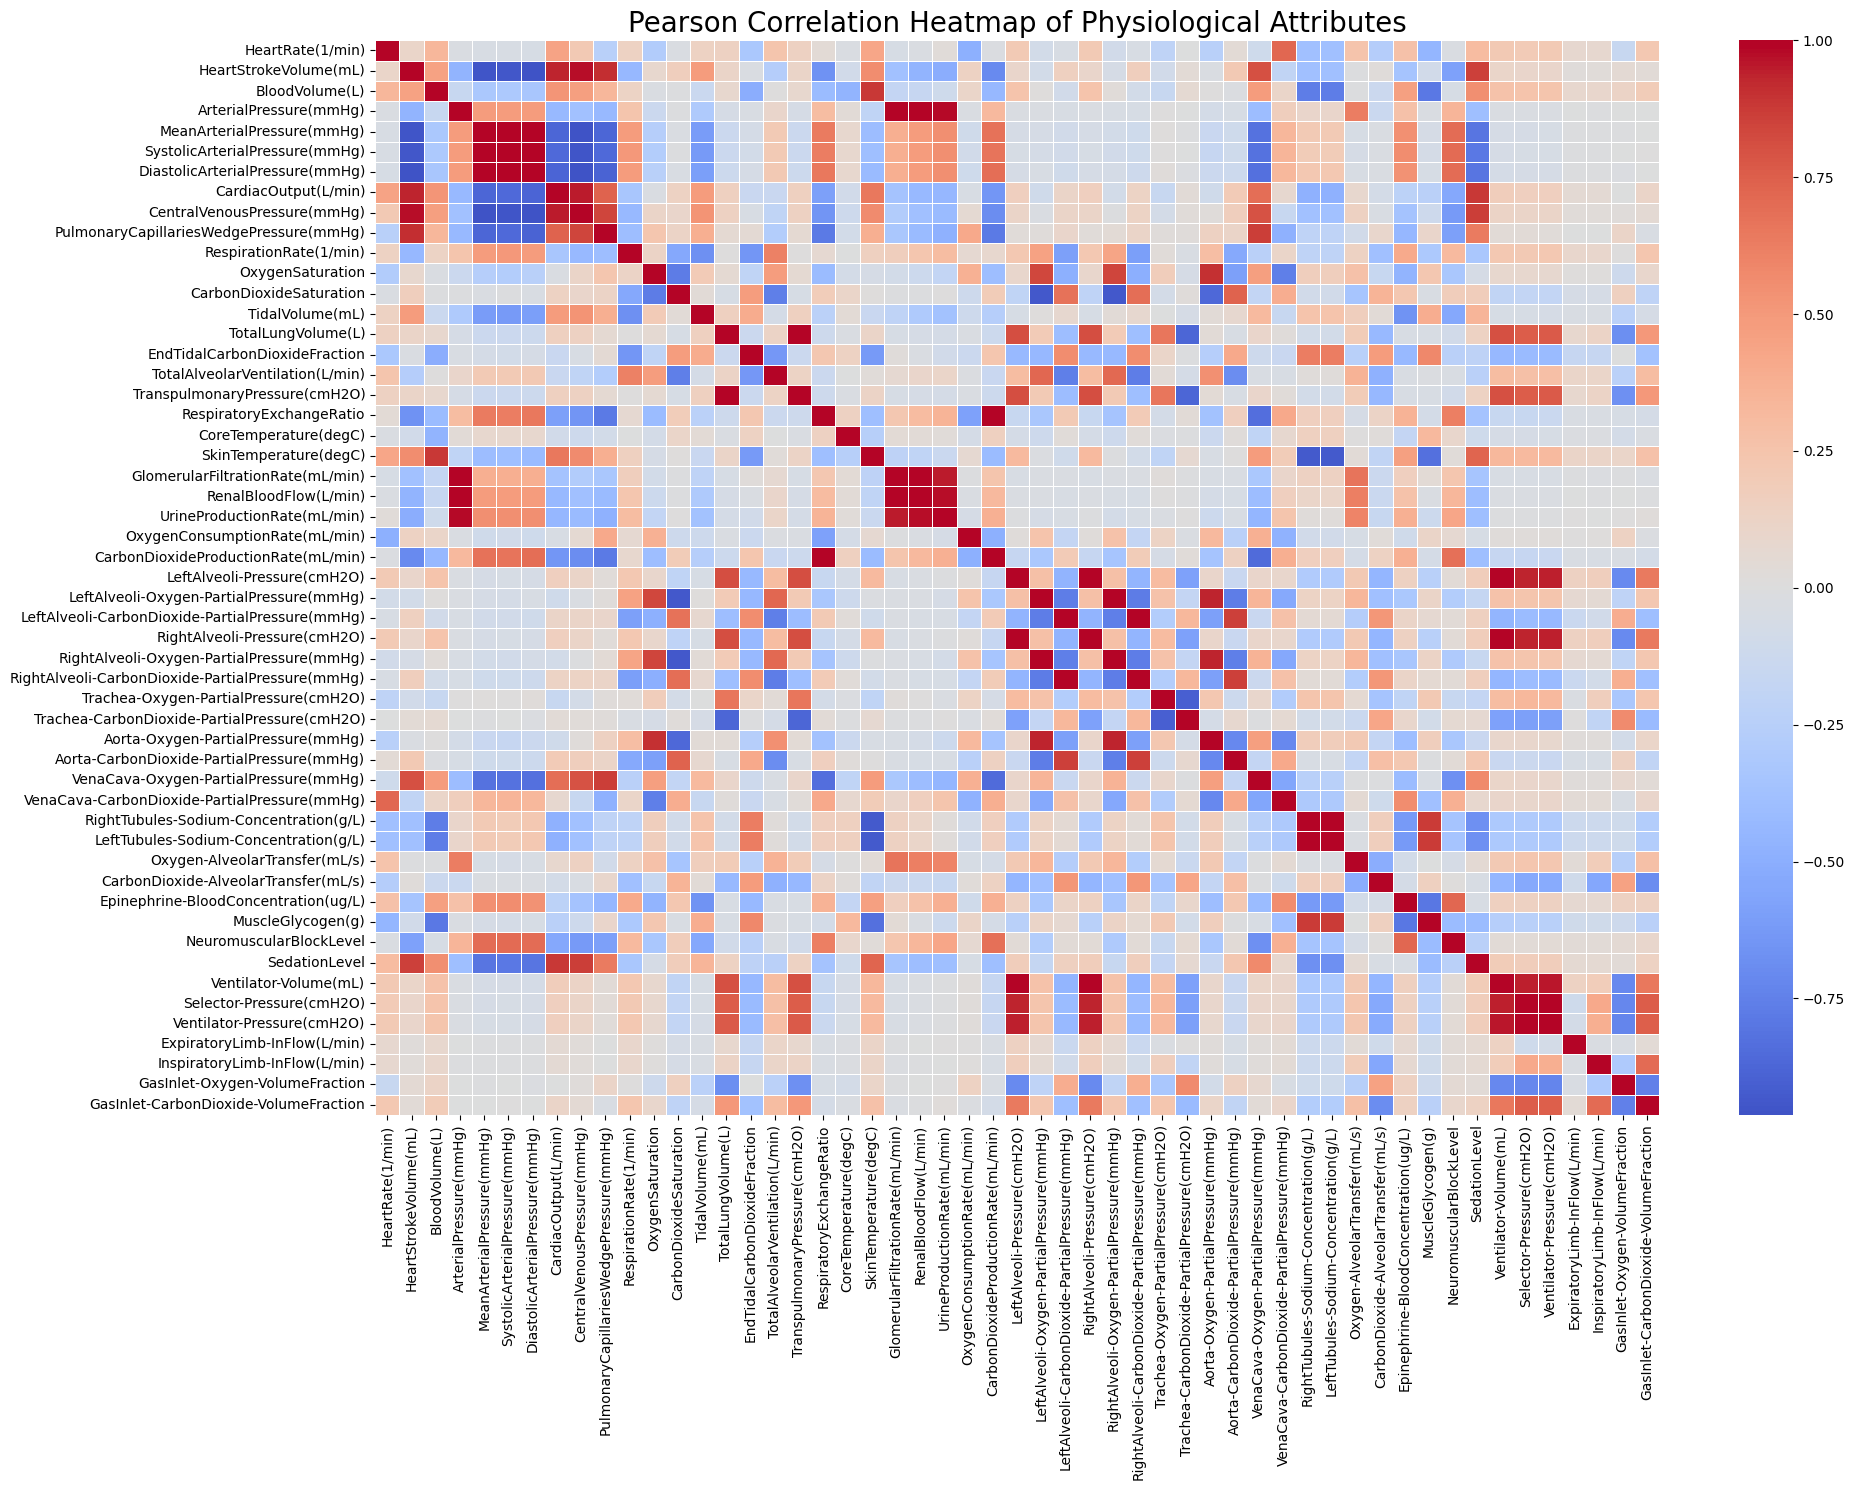

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the figure size for a 53x53 matrix to ensure readability
plt.figure(figsize=(20, 15))

# 2. Create the heatmap using the corr_matrix from the previous step
# We set annot=False to avoid clutter, and use a diverging color map centered at 0
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    cbar=True,
    linewidths=0.5,
    xticklabels=True,
    yticklabels=True
)

# 3. Add title and adjust layout
plt.title('Pearson Correlation Heatmap of Physiological Attributes', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# 4. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the strongest positive and negative correlations found in the data to provide insights into physiological relationships.


## Summary:

### Q&A

**What are the strongest positive and negative correlations found in the physiological data?**
*   **Strongest Positive Correlations:** Near-perfect correlations (r $\approx$ 1.0) exist between bilateral physiological metrics, such as Left and Right Tubules Sodium Concentration (1.00) and Left/Right Alveoli Pressures (0.999). Other strong relationships include Total Lung Volume vs. Transpulmonary Pressure (0.999).
*   **Strongest Negative Correlations:** The most significant negative relationship is between Central Venous Pressure and Diastolic Arterial Pressure (-0.962). Additionally, Carbon Dioxide Saturation is strongly inversely related to Alveoli Oxygen Partial Pressure (-0.935).

### Data Analysis Key Findings

*   **Data Refinement:** The initial dataset was reduced to **53 varying numerical physiological attributes** after removing non-numerical labels (`scenario`), time markers (`Time(s)`), and 8 constant columns with zero variance (e.g., Patient Weight and Hemoglobin Content).
*   **Bilateral Symmetry:** The analysis confirmed extreme positive correlations (r = 1.00) between identical metrics for left and right organs, validating the internal consistency of the physiological model.
*   **Pressure Relationships:** Heart Stroke Volume exhibited a consistent and significant negative correlation with all arterial pressure metrics (Diastolic, Mean, and Systolic).
*   **Respiratory Inverse Dynamics:** A strong negative correlation (-0.935) between CO2 saturation and Alveoli Oxygen Partial Pressure highlights the expected gas exchange trade-offs.
*   **Visual Patterns:** The generated 20x15 heatmap revealed distinct clusters of physiological dependencies, particularly among pressure-related and renal-related metrics.

### Insights or Next Steps

*   **Feature Redundancy:** Given the near-perfect correlations between bilateral organ metrics (e.g., Left vs. Right Tubules), one of the two variables could likely be dropped in future machine learning models to reduce dimensionality without losing information.
*   **Focus on Outliers:** Next steps should involve investigating the specific "scenarios" where these strong correlations might weaken, as those instances could represent physiological anomalies or medical emergencies.


# Task
Filter the dataset from "/content/merged_consistent_scenarios.csv" to keep only the following columns: 'Time(s)', 'HeartRate(1/min)', 'MeanArterialPressure(mmHg)', 'OxygenSaturation', 'RespirationRate(1/min)', 'CardiacOutput(L/min)', 'EndTidalCarbonDioxideFraction', 'TidalVolume(mL)', 'SystolicArterialPressure(mmHg)', 'DiastolicArterialPressure(mmHg)', 'CentralVenousPressure(mmHg)', 'CarbonDioxideSaturation', 'TotalAlveolarVentilation(L/min)', 'OxygenConsumptionRate(mL/min)', and 'CarbonDioxideProductionRate(mL/min)'. Calculate the Pearson correlation matrix for this specific subset of attributes, excluding 'Time(s)'. Generate a Seaborn heatmap for these filtered attributes with numerical annotations enabled to provide a detailed view of their relationships. Finally, summarize the findings from this focused correlation analysis and provide insights on the relationships between these primary physiological markers.

## Filter Specific Attributes

### Subtask:
Filter the dataset to keep only the 15 specified physiological and temporal columns.


**Reasoning**:
I will load the dataset and filter it to include only the 15 specified physiological and temporal columns as requested in the subtask instructions.



In [ ]:
import pandas as pd

# 1. Load the dataset into df_filtered
df_filtered = pd.read_csv('/content/merged_consistent_scenarios.csv')

# 2. Define the list of 15 specified column names
selected_columns = [
    'Time(s)',
    'HeartRate(1/min)',
    'MeanArterialPressure(mmHg)',
    'OxygenSaturation',
    'RespirationRate(1/min)',
    'CardiacOutput(L/min)',
    'EndTidalCarbonDioxideFraction',
    'TidalVolume(mL)',
    'SystolicArterialPressure(mmHg)',
    'DiastolicArterialPressure(mmHg)',
    'CentralVenousPressure(mmHg)',
    'CarbonDioxideSaturation',
    'TotalAlveolarVentilation(L/min)',
    'OxygenConsumptionRate(mL/min)',
    'CarbonDioxideProductionRate(mL/min)'
]

# 3. Filter the DataFrame
df_filtered = df_filtered[selected_columns]

# 4. Display the first few rows and shape to verify
print(f"DataFrame shape after filtering: {df_filtered.shape}")
display(df_filtered.head())

DataFrame shape after filtering: (100081, 15)


,Time(s),HeartRate(1/min),MeanArterialPressure(mmHg),OxygenSaturation,RespirationRate(1/min),CardiacOutput(L/min),EndTidalCarbonDioxideFraction,TidalVolume(mL),SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),CentralVenousPressure(mmHg),CarbonDioxideSaturation,TotalAlveolarVentilation(L/min),OxygenConsumptionRate(mL/min),CarbonDioxideProductionRate(mL/min)
0,0.02,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.92,0.029,6.99,241.422,226.548
1,0.04,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548
2,0.06,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548
3,0.08,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.94,0.029,6.99,241.422,226.548
4,0.10,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.95,0.029,6.99,241.422,226.548


## Update Correlation Matrix

### Subtask:
Calculate the Pearson correlation matrix for the filtered subset of physiological attributes, excluding the temporal column.


**Reasoning**:
I will calculate the Pearson correlation matrix for the filtered subset of physiological attributes, excluding 'Time(s)', and identify the strongest correlations to fulfill the subtask instructions.



In [ ]:
import pandas as pd

# 1. Create a numeric-only DataFrame by dropping 'Time(s)'
df_numeric = df_filtered.drop(columns=['Time(s)'])

# 2. Compute the Pearson correlation matrix
filtered_corr_matrix = df_numeric.corr(method='pearson')

# 3. Flatten the matrix to identify the strongest relationships
corr_series = filtered_corr_matrix.unstack()
# Remove self-correlations
corr_series = corr_series[corr_series.index.get_level_values(0) < corr_series.index.get_level_values(1)]

# 4. Identify strongest positive and negative correlations
top_pos = corr_series.sort_values(ascending=False).head(5)
top_neg = corr_series.sort_values(ascending=True).head(5)

print("--- Top 5 Positive Correlations ---")
print(top_pos)
print("\n--- Top 5 Negative Correlations ---")
print(top_neg)

# Display the matrix
display(filtered_corr_matrix)

--- Top 5 Positive Correlations ---
DiastolicArterialPressure(mmHg)      MeanArterialPressure(mmHg)         0.999178
MeanArterialPressure(mmHg)           SystolicArterialPressure(mmHg)     0.998373
DiastolicArterialPressure(mmHg)      SystolicArterialPressure(mmHg)     0.996166
CardiacOutput(L/min)                 CentralVenousPressure(mmHg)        0.952520
CarbonDioxideProductionRate(mL/min)  DiastolicArterialPressure(mmHg)    0.688687
dtype: float64

--- Top 5 Negative Correlations ---
CentralVenousPressure(mmHg)  DiastolicArterialPressure(mmHg)   -0.962444
                             MeanArterialPressure(mmHg)        -0.956695
                             SystolicArterialPressure(mmHg)    -0.949496
CardiacOutput(L/min)         DiastolicArterialPressure(mmHg)   -0.884633
                             MeanArterialPressure(mmHg)        -0.875208
dtype: float64


,HeartRate(1/min),MeanArterialPressure(mmHg),OxygenSaturation,RespirationRate(1/min),CardiacOutput(L/min),EndTidalCarbonDioxideFraction,TidalVolume(mL),SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),CentralVenousPressure(mmHg),CarbonDioxideSaturation,TotalAlveolarVentilation(L/min),OxygenConsumptionRate(mL/min),CarbonDioxideProductionRate(mL/min)
HeartRate(1/min),1.000000,-0.049417,-0.282239,0.133953,0.443047,-0.322113,0.137737,-0.044992,-0.050495,0.215664,-0.029202,0.241201,-0.490538,-0.017970
MeanArterialPressure(mmHg),-0.049417,1.000000,-0.260227,0.493624,-0.875208,-0.069027,-0.612156,0.998373,0.999178,-0.956695,-0.020638,0.207088,-0.099714,0.676603
OxygenSaturation,-0.282239,-0.260227,1.000000,0.125739,-0.021376,-0.198618,0.202012,-0.272700,-0.243586,0.117905,-0.775534,0.475433,0.366065,-0.397547
RespirationRate(1/min),0.133953,0.493624,0.125739,1.000000,-0.339601,-0.646499,-0.673889,0.505535,0.489936,-0.427028,-0.533548,0.612494,0.070163,0.083758
CardiacOutput(L/min),0.443047,-0.875208,-0.021376,-0.339601,1.000000,-0.144821,0.482145,-0.862708,-0.884633,0.952520,0.134964,-0.149290,-0.042760,-0.645521
EndTidalCarbonDioxideFraction,-0.322113,-0.069027,-0.198618,-0.646499,-0.144821,1.000000,0.394935,-0.082132,-0.062803,-0.048951,0.476184,-0.639130,-0.128876,0.233848
TidalVolume(mL),0.137737,-0.612156,0.202012,-0.673889,0.482145,0.394935,1.000000,-0.625018,-0.599479,0.530045,0.037598,-0.065777,-0.117779,-0.264414
SystolicArterialPressure(mmHg),-0.044992,0.998373,-0.272700,0.505535,-0.862708,-0.082132,-0.625018,1.000000,0.996166,-0.949496,-0.011287,0.207428,-0.093699,0.666973
DiastolicArterialPressure(mmHg),-0.050495,0.999178,-0.243586,0.489936,-0.884633,-0.062803,-0.599479,0.996166,1.000000,-0.962444,-0.038277,0.214823,-0.106499,0.688687
CentralVenousPressure(mmHg),0.215664,-0.956695,0.117905,-0.427028,0.952520,-0.048951,0.530045,-0.949496,-0.962444,1.000000,0.098295,-0.201318,0.059284,-0.692794


**Reasoning**:
The correlation matrix for the 14 physiological attributes has been calculated. The final step is to visualize this matrix using a Seaborn heatmap with annotations as requested.



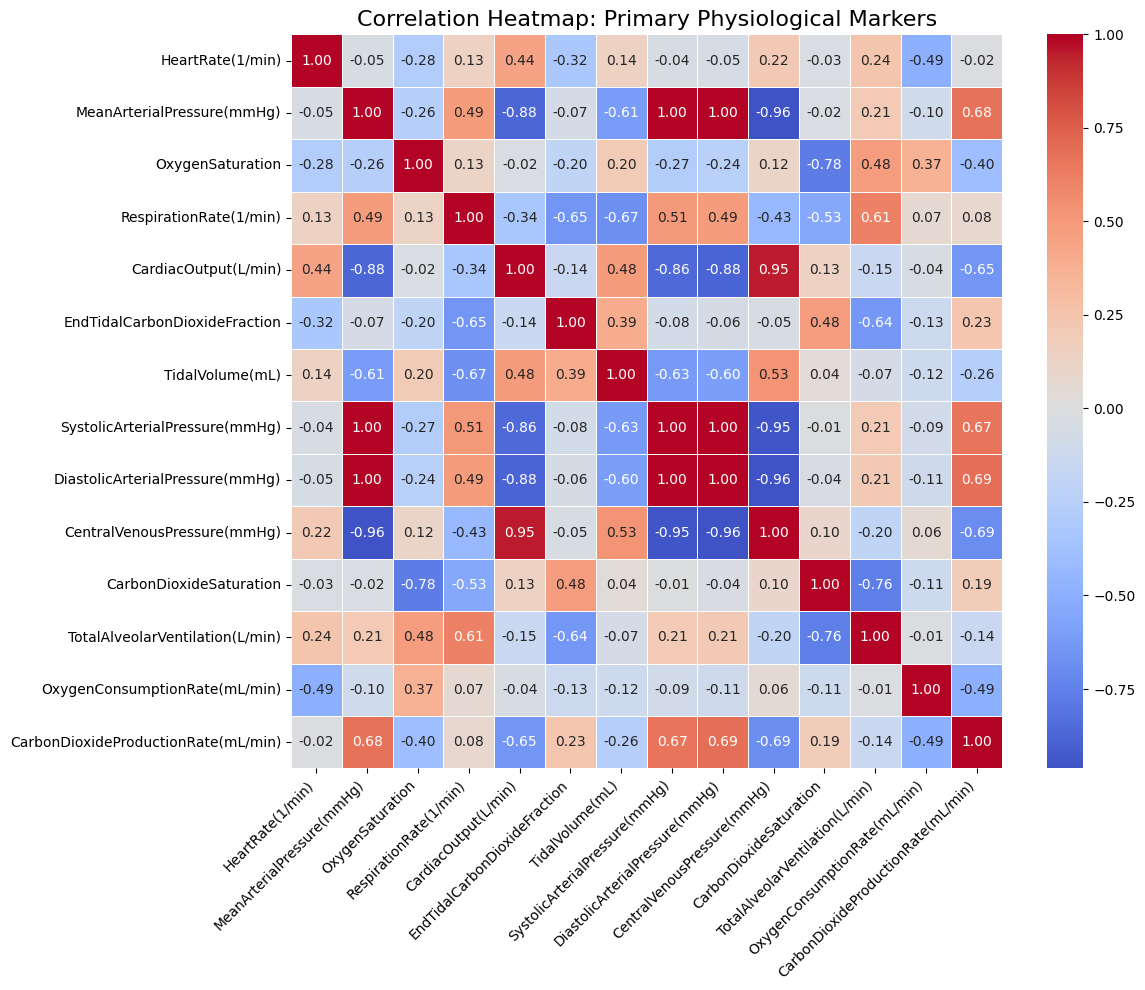

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the figure size for a readable 14x14 heatmap
plt.figure(figsize=(12, 10))

# 2. Create the heatmap with annotations
sns.heatmap(
    filtered_corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

# 3. Add titles and labels
plt.title('Correlation Heatmap: Primary Physiological Markers', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# 4. Show the plot
plt.show()

## Final Task

### Subtask:
Summarize the findings from the focused correlation analysis of primary physiological markers.


## Summary:

### Q&A

**What are the primary physiological relationships identified in the dataset?**
The analysis revealed several critical relationships:
*   **Arterial Pressure:** Diastolic, Mean, and Systolic pressures are almost perfectly correlated (\> 0.99).
*   **Cardiac Dynamics:** There is a very strong positive link between Central Venous Pressure and Cardiac Output (0.95), while both are inversely related to arterial pressures (approx. -0.95).
*   **Respiratory Exchange:** Oxygen and Carbon Dioxide saturation show a strong inverse relationship (-0.78), and increased Alveolar Ventilation effectively reduces $CO_2$ saturation (-0.76).

### Data Analysis Key Findings

*   **Near-Perfect Multicollinearity in Blood Pressure:** `MeanArterialPressure`, `SystolicArterialPressure`, and `DiastolicArterialPressure` exhibit correlations exceeding 0.99, indicating they move in near-perfect synchronization within this dataset.
*   **Cardiac-Arterial Inverse Relationship:** A significant negative correlation exists between `CentralVenousPressure` and arterial pressure markers (ranging from -0.95 to -0.96), suggesting a distinct physiological trade-off or state transition in the recorded scenarios.
*   **Venous Return and Output:** `CardiacOutput` and `CentralVenousPressure` are highly positively correlated (0.95), highlighting the dependency of heart output on venous filling pressure.
*   **Gas Exchange Efficiency:** `TotalAlveolarVentilation` shows a strong negative correlation with `CarbonDioxideSaturation` (-0.76) and `EndTidalCarbonDioxideFraction` (-0.64), quantifying the effectiveness of ventilation in $CO_2$ clearance.
*   **Oxygen/CO2 Balance:** `OxygenSaturation` and `CarbonDioxideSaturation` maintain a strong negative correlation of -0.78, reflecting the competitive nature of gas transport in the bloodstream.

### Insights or Next Steps

*   **Feature Redundancy:** Given the near-perfect correlation (r \> 0.99) between the three arterial pressure metrics, future predictive models should likely use only one (e.g., Mean Arterial Pressure) to avoid multicollinearity issues.
*   **Focus on Outliers:** Investigate segments where the strong relationship between `CardiacOutput` and `CentralVenousPressure` deviates, as these may represent critical physiological events or compensatory failures.


In [ ]:
from google.colab import files

# Save the filtered subset to a CSV file
output_path = '/content/filtered_physiological_scenarios.csv'
df_final_subset.to_csv(output_path, index=False)

print(f'File saved to {output_path}')

# Trigger the download
files.download(output_path)

File saved to /content/filtered_physiological_scenarios.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Define the requested columns plus 'scenario'
selected_columns = [
    'Time(s)',
    'HeartRate(1/min)',
    'MeanArterialPressure(mmHg)',
    'OxygenSaturation',
    'RespirationRate(1/min)',
    'CardiacOutput(L/min)',
    'EndTidalCarbonDioxideFraction',
    'TidalVolume(mL)',
    'SystolicArterialPressure(mmHg)',
    'DiastolicArterialPressure(mmHg)',
    'CentralVenousPressure(mmHg)',
    'CarbonDioxideSaturation',
    'TotalAlveolarVentilation(L/min)',
    'OxygenConsumptionRate(mL/min)',
    'CarbonDioxideProductionRate(mL/min)',
    'scenario'
]

# Load the consistent dataset
df_merged = pd.read_csv('/content/merged_consistent_scenarios.csv')

# Filter to keep only the specified columns
df_final_subset = df_merged[selected_columns]

# Verify and display
print(f"Filtered DataFrame shape: {df_final_subset.shape}")
display(df_final_subset.head())

Filtered DataFrame shape: (100081, 16)


,Time(s),HeartRate(1/min),MeanArterialPressure(mmHg),OxygenSaturation,RespirationRate(1/min),CardiacOutput(L/min),EndTidalCarbonDioxideFraction,TidalVolume(mL),SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),CentralVenousPressure(mmHg),CarbonDioxideSaturation,TotalAlveolarVentilation(L/min),OxygenConsumptionRate(mL/min),CarbonDioxideProductionRate(mL/min),scenario
0,0.02,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.92,0.029,6.99,241.422,226.548,anesthesia
1,0.04,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548,anesthesia
2,0.06,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548,anesthesia
3,0.08,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.94,0.029,6.99,241.422,226.548,anesthesia
4,0.10,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.95,0.029,6.99,241.422,226.548,anesthesia


In [ ]:
# 1. Get unique scenario labels
labels = df_final_subset['scenario'].unique().tolist()
print(f"Scenario Labels: {labels}")

# 2. Create a version without the scenario column
df_no_scenario = df_final_subset.drop(columns=['scenario'])

# 3. Verify
print(f"\nNew DataFrame shape (without scenario): {df_no_scenario.shape}")
display(df_no_scenario.head())

Scenario Labels: ['anesthesia', 'oxygen_tank', 'oxygen_wall', 'valve_obstruction', 'ventilator_failure', 'valve_leak']

New DataFrame shape (without scenario): (100081, 15)


,Time(s),HeartRate(1/min),MeanArterialPressure(mmHg),OxygenSaturation,RespirationRate(1/min),CardiacOutput(L/min),EndTidalCarbonDioxideFraction,TidalVolume(mL),SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),CentralVenousPressure(mmHg),CarbonDioxideSaturation,TotalAlveolarVentilation(L/min),OxygenConsumptionRate(mL/min),CarbonDioxideProductionRate(mL/min)
0,0.02,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.92,0.029,6.99,241.422,226.548
1,0.04,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548
2,0.06,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548
3,0.08,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.94,0.029,6.99,241.422,226.548
4,0.10,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.95,0.029,6.99,241.422,226.548


In [ ]:
import pandas as pd

# 1. Create a copy of the filtered dataset
df_labeled = df_final_subset.copy()

# 2. Convert 'scenario' to a categorical type
df_labeled['scenario_label'] = df_labeled['scenario'].astype('category')

# 3. Create a numeric 'label' column (0-5)
df_labeled['label'] = df_labeled['scenario_label'].cat.codes

# 4. Create a mapping dictionary for reference
label_mapping = dict(enumerate(df_labeled['scenario_label'].cat.categories))

print("Label Mapping:")
for code, name in label_mapping.items():
    print(f"{code}: {name}")

# 5. Display the first few rows including the new numeric label
print("\nNew Labeled Dataset Sample:")
display(df_labeled[['Time(s)', 'HeartRate(1/min)', 'scenario', 'label']].head())

# Final shape check
print(f"\nLabeled DataFrame shape: {df_labeled.shape}")

Label Mapping:
0: anesthesia
1: oxygen_tank
2: oxygen_wall
3: valve_leak
4: valve_obstruction
5: ventilator_failure

New Labeled Dataset Sample:


,Time(s),HeartRate(1/min),scenario,label
0,0.02,72.0,anesthesia,0
1,0.04,72.0,anesthesia,0
2,0.06,72.0,anesthesia,0
3,0.08,72.0,anesthesia,0
4,0.10,72.0,anesthesia,0



Labeled DataFrame shape: (100081, 18)


In [ ]:
# Remove 'scenario' and 'scenario_label' columns
df_final_labeled = df_labeled.drop(columns=['scenario', 'scenario_label'])

# Display the cleaned numeric DataFrame
print(f"Final DataFrame shape: {df_final_labeled.shape}")
display(df_final_labeled.head())

# Show the last few columns to confirm 'label' is present
print("\nLast 5 columns:")
print(df_final_labeled.columns[-5:].tolist())

Final DataFrame shape: (100081, 16)


,Time(s),HeartRate(1/min),MeanArterialPressure(mmHg),OxygenSaturation,RespirationRate(1/min),CardiacOutput(L/min),EndTidalCarbonDioxideFraction,TidalVolume(mL),SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),CentralVenousPressure(mmHg),CarbonDioxideSaturation,TotalAlveolarVentilation(L/min),OxygenConsumptionRate(mL/min),CarbonDioxideProductionRate(mL/min),label
0,0.02,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.92,0.029,6.99,241.422,226.548,0
1,0.04,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548,0
2,0.06,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.93,0.029,6.99,241.422,226.548,0
3,0.08,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.94,0.029,6.99,241.422,226.548,0
4,0.10,72.0,95.9,0.979,15.96,5.78,0.0434,514,115,74.5,3.95,0.029,6.99,241.422,226.548,0



Last 5 columns:
['CarbonDioxideSaturation', 'TotalAlveolarVentilation(L/min)', 'OxygenConsumptionRate(mL/min)', 'CarbonDioxideProductionRate(mL/min)', 'label']


In [ ]:
from google.colab import files

# Save the labeled dataset to a CSV file
output_labeled_path = '/content/labeled_physiological_scenarios.csv'
df_labeled.to_csv(output_labeled_path, index=False)

print(f'Labeled file saved to: {output_labeled_path}')

# Trigger the download
files.download(output_labeled_path)

Labeled file saved to: /content/labeled_physiological_scenarios.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Save the final numeric labeled dataset to a CSV file
final_output_path = '/content/final_numeric_physiological_dataset.csv'
df_final_labeled.to_csv(final_output_path, index=False)

print(f'Final numeric file saved to: {final_output_path}')

# Trigger the download
files.download(final_output_path)

Final numeric file saved to: /content/final_numeric_physiological_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Load the numeric dataset
df_vif = pd.read_csv('/content/final_numeric_physiological_dataset.csv')

# 2. Drop 'label' and 'Time(s)' as they are not physiological predictors
X = df_vif.drop(columns=['label', 'Time(s)'])

# 3. Clean the data: Remove Infs and NaNs which cause the MissingDataError
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# 4. Add a constant term for VIF calculation
X_const = add_constant(X)

# 5. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]

# 6. Sort by VIF descending
vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

print(f'Variance Inflation Factor (VIF) Results (Cleaned Rows: {len(X)}):')
display(vif_data)

Variance Inflation Factor (VIF) Results (Cleaned Rows: 72247):


,feature,VIF
0,MeanArterialPressure(mmHg),5331.065933
1,DiastolicArterialPressure(mmHg),5268.889099
2,SystolicArterialPressure(mmHg),531.648611
3,CardiacOutput(L/min),215.397823
4,CentralVenousPressure(mmHg),40.752547
5,HeartRate(1/min),19.407516
6,CarbonDioxideSaturation,13.422574
7,EndTidalCarbonDioxideFraction,8.272475
8,OxygenSaturation,7.892816
9,CarbonDioxideProductionRate(mL/min),7.447438


### Interpretation of Collinearity Results

- **VIF = 1**: No correlation between the feature and others.
- **1 < VIF < 5**: Moderate correlation, usually acceptable.
- **VIF > 5 or 10**: High multicollinearity. These variables are highly redundant and can make model coefficients unstable.

Based on the correlation heatmap we generated earlier, we expect extremely high VIF values for the three **Arterial Pressure** metrics and **Cardiac Output/CVP** pairs.

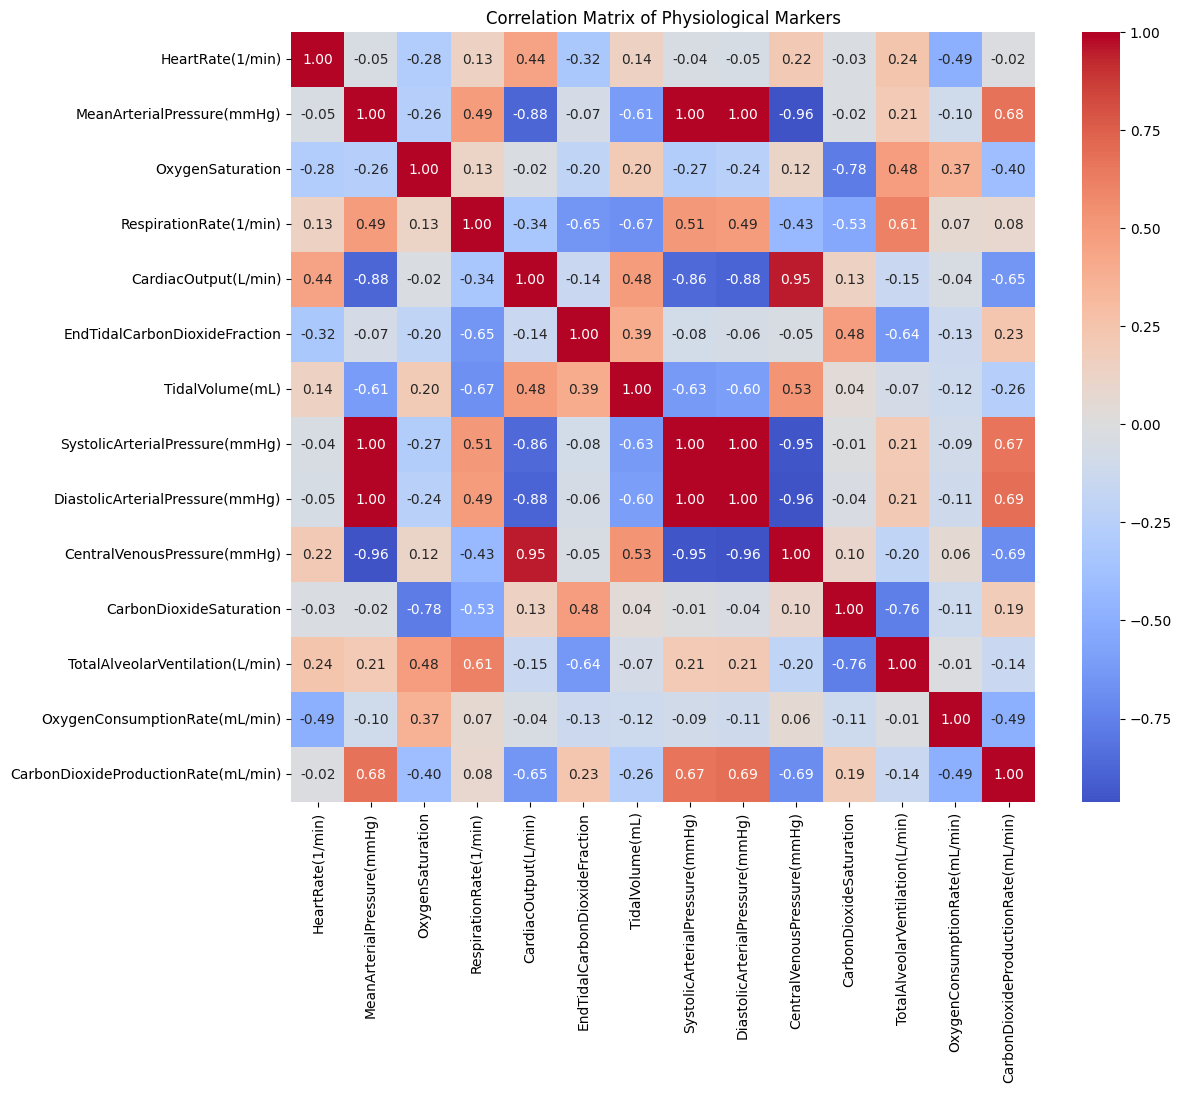

Top Positive Correlations:


,,0
HeartRate(1/min),HeartRate(1/min),1.000000
DiastolicArterialPressure(mmHg),MeanArterialPressure(mmHg),0.999178
MeanArterialPressure(mmHg),SystolicArterialPressure(mmHg),0.998373
SystolicArterialPressure(mmHg),DiastolicArterialPressure(mmHg),0.996166
CentralVenousPressure(mmHg),CardiacOutput(L/min),0.952520
DiastolicArterialPressure(mmHg),CarbonDioxideProductionRate(mL/min),0.688687
MeanArterialPressure(mmHg),CarbonDioxideProductionRate(mL/min),0.676603
CarbonDioxideProductionRate(mL/min),SystolicArterialPressure(mmHg),0.666973
TotalAlveolarVentilation(L/min),RespirationRate(1/min),0.612494
TidalVolume(mL),CentralVenousPressure(mmHg),0.530045


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the final numeric dataset
df_final = pd.read_csv('/content/final_numeric_physiological_dataset.csv')

# Remove non-physiological columns for correlation
df_physio = df_final.drop(columns=['label', 'Time(s)'])

# Calculate Pearson correlation matrix
corr_matrix = df_physio.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Physiological Markers')
plt.show()

# Display top correlations
print('Top Positive Correlations:')
display(corr_matrix.unstack().sort_values(ascending=False).drop_duplicates().head(10))